# Amazon Review Analytics - ETU20240090 - KuanYu HOU

## 1. Understanding the Context and Defining Objectives 

#### Improve customer satisfaction by identifying common complaints and issues.
#### Enhance product quality by flagging products with consistent negative reviews.
#### Boost sales by promoting products with consistently high ratings and addressing negative feedback proactively.

## 2. Data Collection and Preparation

In [5]:
#Import required libraries

In [6]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [7]:
#read hotel booking csv file

In [8]:
df = pd.read_csv("Amazon_Reviews.csv")
df.head()

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...


In [9]:
#data infomation
df.shape

(568454, 10)

In [10]:
df

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...
...,...,...,...,...,...,...,...,...,...,...
568449,568450,B001EO7N10,A28KG5XORO54AY,Lettie D. Carter,0,0,5,1299628800,Will not do without,Great for sesame chicken..this is a good if no...
568450,568451,B003S1WTCU,A3I8AFVPEE8KI5,R. Sawyer,0,0,2,1331251200,disappointed,I'm disappointed with the flavor. The chocolat...
568451,568452,B004I613EE,A121AA1GQV751Z,"pksd ""pk_007""",2,2,5,1329782400,Perfect for our maltipoo,"These stars are small, so you can give 10-15 o..."
568452,568453,B004I613EE,A3IBEVCTXKNOH,"Kathy A. Welch ""katwel""",1,1,5,1331596800,Favorite Training and reward treat,These are the BEST treats for training and rew...


In [11]:
df.columns

Index(['Id', 'ProductId', 'UserId', 'ProfileName', 'HelpfulnessNumerator',
       'HelpfulnessDenominator', 'Score', 'Time', 'Summary', 'Text'],
      dtype='object')

In [12]:
df.duplicated()

0         False
1         False
2         False
3         False
4         False
          ...  
568449    False
568450    False
568451    False
568452    False
568453    False
Length: 568454, dtype: bool

In [13]:
#find missing values
missing_value = df.isna().sum()
missing_value

Id                         0
ProductId                  0
UserId                     0
ProfileName               26
HelpfulnessNumerator       0
HelpfulnessDenominator     0
Score                      0
Time                       0
Summary                   27
Text                       0
dtype: int64

In [14]:
#[]進行篩選布林索引 
print(missing_value[missing_value>0])

ProfileName    26
Summary        27
dtype: int64


In [15]:
#remove missing values
df_clean = df.dropna(subset=['ProfileName','Summary'])
df_clean

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...
...,...,...,...,...,...,...,...,...,...,...
568449,568450,B001EO7N10,A28KG5XORO54AY,Lettie D. Carter,0,0,5,1299628800,Will not do without,Great for sesame chicken..this is a good if no...
568450,568451,B003S1WTCU,A3I8AFVPEE8KI5,R. Sawyer,0,0,2,1331251200,disappointed,I'm disappointed with the flavor. The chocolat...
568451,568452,B004I613EE,A121AA1GQV751Z,"pksd ""pk_007""",2,2,5,1329782400,Perfect for our maltipoo,"These stars are small, so you can give 10-15 o..."
568452,568453,B004I613EE,A3IBEVCTXKNOH,"Kathy A. Welch ""katwel""",1,1,5,1331596800,Favorite Training and reward treat,These are the BEST treats for training and rew...


In [16]:
# Convert the 'Time' column (UNIX time) to a datetime format
# unit='s' second
df_clean['Time'] = pd.to_datetime(df_clean['Time'], unit='s')

/var/folders/w5/4b9h2mj12mg7pq05x401t0kr0000gn/T/ipykernel_36460/1484029788.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['Time'] = pd.to_datetime(df_clean['Time'], unit='s')


In [17]:
df_clean

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,2011-04-27,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,2012-09-07,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,2008-08-18,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,2011-06-13,Cough Medicine,If you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,2012-10-21,Great taffy,Great taffy at a great price. There was a wid...
...,...,...,...,...,...,...,...,...,...,...
568449,568450,B001EO7N10,A28KG5XORO54AY,Lettie D. Carter,0,0,5,2011-03-09,Will not do without,Great for sesame chicken..this is a good if no...
568450,568451,B003S1WTCU,A3I8AFVPEE8KI5,R. Sawyer,0,0,2,2012-03-09,disappointed,I'm disappointed with the flavor. The chocolat...
568451,568452,B004I613EE,A121AA1GQV751Z,"pksd ""pk_007""",2,2,5,2012-02-21,Perfect for our maltipoo,"These stars are small, so you can give 10-15 o..."
568452,568453,B004I613EE,A3IBEVCTXKNOH,"Kathy A. Welch ""katwel""",1,1,5,2012-03-13,Favorite Training and reward treat,These are the BEST treats for training and rew...


In [18]:
# Basic text cleaning: Removing unnecessary characters in 'Text'
df_clean['Text'] = df_clean['Text'].str.replace(r'[^a-zA-Z0-9\s]', '', regex=True)

/var/folders/w5/4b9h2mj12mg7pq05x401t0kr0000gn/T/ipykernel_36460/1746127252.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['Text'] = df_clean['Text'].str.replace(r'[^a-zA-Z0-9\s]', '', regex=True)


In [19]:
df_clean

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,2011-04-27,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,2012-09-07,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,2008-08-18,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,2011-06-13,Cough Medicine,If you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,2012-10-21,Great taffy,Great taffy at a great price There was a wide...
...,...,...,...,...,...,...,...,...,...,...
568449,568450,B001EO7N10,A28KG5XORO54AY,Lettie D. Carter,0,0,5,2011-03-09,Will not do without,Great for sesame chickenthis is a good if not ...
568450,568451,B003S1WTCU,A3I8AFVPEE8KI5,R. Sawyer,0,0,2,2012-03-09,disappointed,Im disappointed with the flavor The chocolate ...
568451,568452,B004I613EE,A121AA1GQV751Z,"pksd ""pk_007""",2,2,5,2012-02-21,Perfect for our maltipoo,These stars are small so you can give 1015 of ...
568452,568453,B004I613EE,A3IBEVCTXKNOH,"Kathy A. Welch ""katwel""",1,1,5,2012-03-13,Favorite Training and reward treat,These are the BEST treats for training and rew...


## 3. Exploratory Data Analysis (EDA) 

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

/var/folders/w5/4b9h2mj12mg7pq05x401t0kr0000gn/T/ipykernel_36460/342790493.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Score', data=df_clean,palette='pastel')


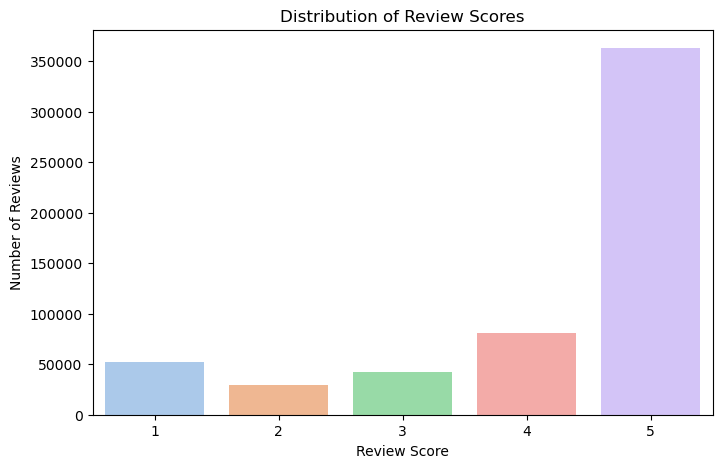

In [22]:
# Distribution of review scores
plt.figure(figsize=(8,5))
sns.countplot(x='Score', data=df_clean,palette='pastel')
plt.title('Distribution of Review Scores')
plt.xlabel('Review Score')
plt.ylabel('Number of Reviews')
plt.show()

/var/folders/w5/4b9h2mj12mg7pq05x401t0kr0000gn/T/ipykernel_36460/3578998331.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['Year'] = df_clean['Time'].dt.year


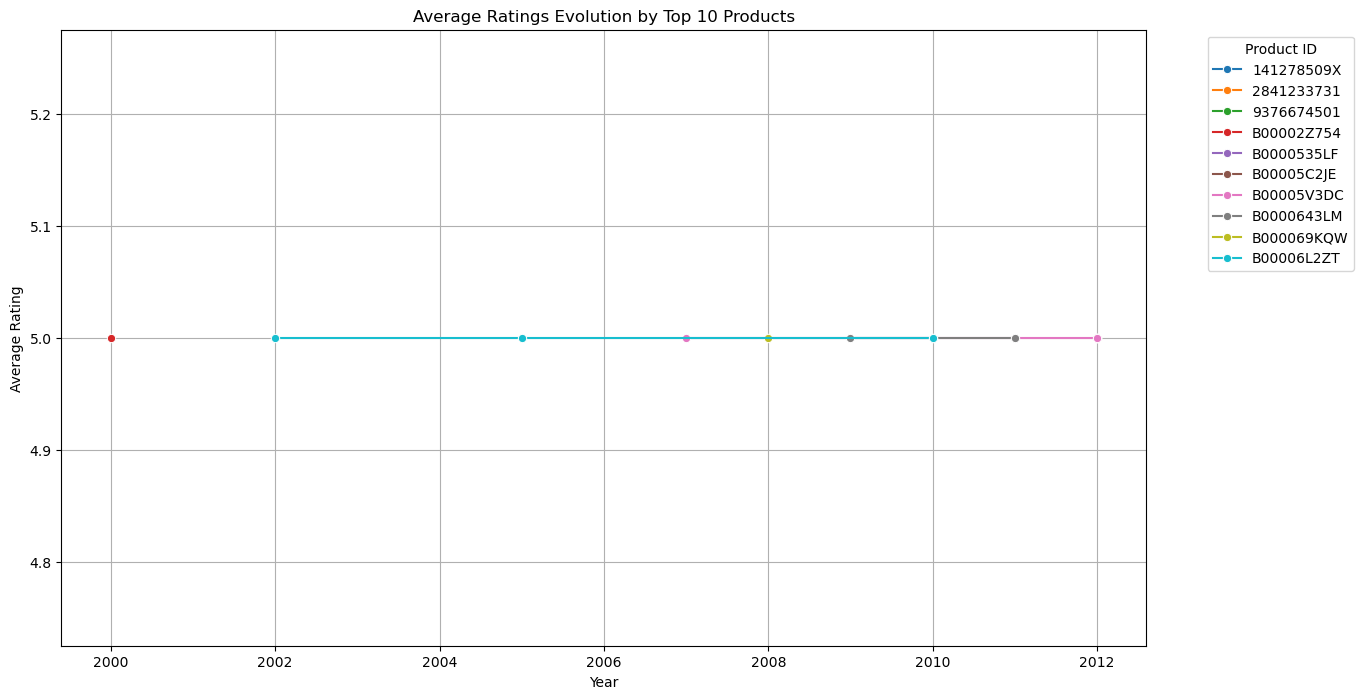

In [23]:
# 提取年份
df_clean['Year'] = df_clean['Time'].dt.year

# 計算每個產品每年的平均評分
average_rating_per_product = df_clean.groupby(['ProductId', 'Year'])['Score'].mean().reset_index()

# 找出前十個產品
top_products = average_rating_per_product.groupby('ProductId')['Score'].mean().nlargest(10).index

# 選擇前十個產品的數據
top_average_rating_per_product = average_rating_per_product[average_rating_per_product['ProductId'].isin(top_products)]

# 可視化
plt.figure(figsize=(14, 8))

# 使用 Seaborn 繪製折線圖，顯示前十個產品的平均評分
sns.lineplot(data=top_average_rating_per_product, x='Year', y='Score', hue='ProductId', marker='o')

plt.title('Average Ratings Evolution by Top 10 Products')
plt.xlabel('Year')
plt.ylabel('Average Rating')
plt.legend(title='Product ID', bbox_to_anchor=(1.05, 1), loc='upper left')  # 調整圖例的位置
plt.grid(True)  # 添加網格線
plt.show()

In [24]:
# 提取年份
df_clean['Year'] = df_clean['Time'].dt.year

# 計算每個產品每年的平均評分
average_rating_per_product = df_clean.groupby(['ProductId', 'Year'])['Score'].mean().reset_index()

# 找出前十個產品
top_products = average_rating_per_product.groupby('ProductId')['Score'].mean().nlargest(10).index
top_products

/var/folders/w5/4b9h2mj12mg7pq05x401t0kr0000gn/T/ipykernel_36460/2277879914.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['Year'] = df_clean['Time'].dt.year


Index(['141278509X', '2841233731', '9376674501', 'B00002Z754', 'B0000535LF',
       'B00005C2JE', 'B00005V3DC', 'B0000643LM', 'B000069KQW', 'B00006L2ZT'],
      dtype='object', name='ProductId')

/var/folders/w5/4b9h2mj12mg7pq05x401t0kr0000gn/T/ipykernel_36460/2351523496.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['Sentiment'] = df_clean['Score'].apply(lambda x: 'Positive' if x > 3 else 'Negative')


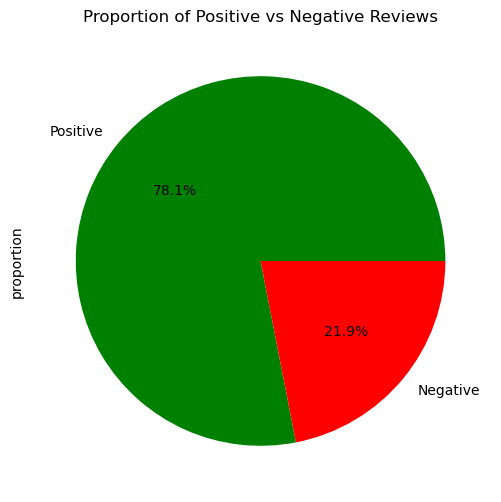

In [25]:
# Proportion of positive vs negative reviews
df_clean['Sentiment'] = df_clean['Score'].apply(lambda x: 'Positive' if x > 3 else 'Negative')
sentiment_distribution = df_clean['Sentiment'].value_counts(normalize=True)

plt.figure(figsize=(6,6))
sentiment_distribution.plot.pie(autopct='%1.1f%%', colors=['green', 'red'])
plt.title('Proportion of Positive vs Negative Reviews')
plt.show()

/var/folders/w5/4b9h2mj12mg7pq05x401t0kr0000gn/T/ipykernel_36460/1421385022.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['Year'] = df_clean['Time'].dt.year


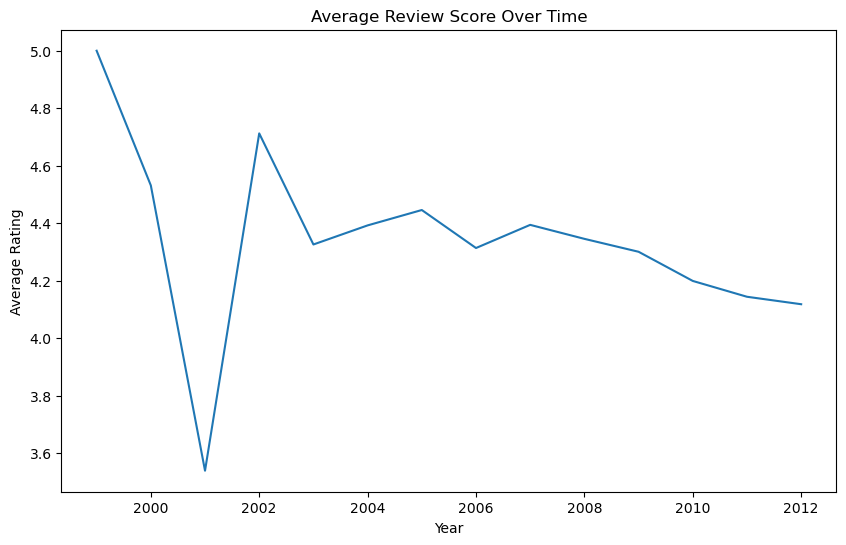

In [26]:
# Average rating over time
df_clean['Year'] = df_clean['Time'].dt.year
average_rating_per_year = df_clean.groupby('Year')['Score'].mean()

plt.figure(figsize=(10,6))
average_rating_per_year.plot()
plt.title('Average Review Score Over Time')
plt.xlabel('Year')
plt.ylabel('Average Rating')
plt.show()

## 4. Analyzing Statistical Measures

In [28]:
# Average rating per product
average_rating_per_product = df_clean.groupby('ProductId')['Score'].mean().reset_index()
average_rating_per_product 

,ProductId,Score
0,0006641040,4.351351
1,141278509X,5.000000
2,2734888454,3.500000
3,2841233731,5.000000
4,7310172001,4.751445
...,...,...
74252,B009UOFTUI,1.000000
74253,B009UOFU20,1.000000
74254,B009UUS05I,5.000000
74255,B009WSNWC4,5.000000


#### HelpfulnessNumerator
##### 定義: 這個欄位表示該評論被標記為“有幫助”的次數。
##### 例子: 如果一個評論得到了 10 次“有幫助”的點擊，那麼 HelpfulnessNumerator 的值就是 10。
#### HelpfulnessDenominator
##### 定義: 這個欄位表示該評論總共被評估的次數，包括“有幫助”和“無幫助”的評估。
##### 例子: 如果同一個評論被總共評估了 15 次（例如 10 次“有幫助” + 5 次“無幫助”），那麼 HelpfulnessDenominator 的值就是 15。
##### 計算有用性比率
##### 這兩個值可以用來計算 有用性比率（Helpfulness Ratio），公式如下：
#### Helpfulness Ratio = HelpfulnessNumerator/HelpfulnessDenominator


In [30]:
# Calculate helpfulness ratio
# create new rows 'HelpfulnessRatio'
df_clean['HelpfulnessRatio'] = df_clean['HelpfulnessNumerator'] / df_clean['HelpfulnessDenominator'].replace(0, 1)
df_clean['HelpfulnessRatio'].fillna(0, inplace=True) #補缺值為0
print(df_clean['HelpfulnessRatio'])

0         1.0
1         0.0
2         1.0
3         1.0
4         0.0
         ... 
568449    0.0
568450    0.0
568451    1.0
568452    1.0
568453    0.0
Name: HelpfulnessRatio, Length: 568401, dtype: float64


/var/folders/w5/4b9h2mj12mg7pq05x401t0kr0000gn/T/ipykernel_36460/508443951.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['HelpfulnessRatio'] = df_clean['HelpfulnessNumerator'] / df_clean['HelpfulnessDenominator'].replace(0, 1)
/var/folders/w5/4b9h2mj12mg7pq05x401t0kr0000gn/T/ipykernel_36460/508443951.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].met

In [31]:
# Review length vs helpfulness correlation
# 計算評論長度 create new rows 'ReviewLength'
df_clean['ReviewLength'] = df_clean['Text'].apply(lambda x: len(x.split()))
# 計算相關性
correlation = df_clean[['ReviewLength', 'HelpfulnessRatio']].corr()

/var/folders/w5/4b9h2mj12mg7pq05x401t0kr0000gn/T/ipykernel_36460/2039822435.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['ReviewLength'] = df_clean['Text'].apply(lambda x: len(x.split()))


In [32]:
print("Correlation between Review Length and Helpfulness Ratio:\n", correlation)
#1 表示完全正相關，即評論長度越長，有用性比率越高。
#-1 表示完全負相關，即評論長度越長，有用性比率越低。
#0 表示沒有相關性，即兩者之間的關係不明顯。
#1 indicates a perfect positive correlation, i.e. the longer the review length, the higher the usefulness ratio.
#-1 indicates a perfect negative correlation, i.e. the longer the review length, the lower the usefulness ratio.
#0 means there is no correlation, that is, the relationship between the two is not obvious.

Correlation between Review Length and Helpfulness Ratio:
                   ReviewLength  HelpfulnessRatio
ReviewLength          1.000000          0.122854
HelpfulnessRatio      0.122854          1.000000


In [33]:
#Visualization

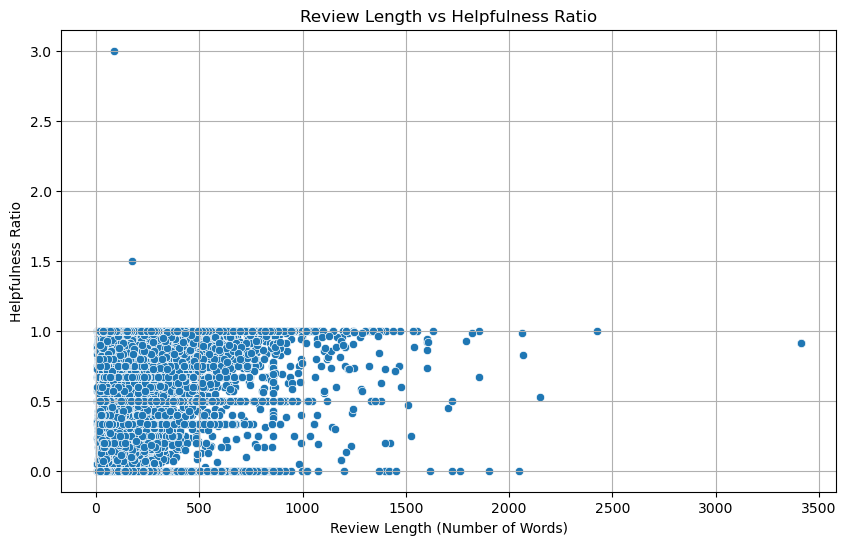

In [34]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_clean, x='ReviewLength', y='HelpfulnessRatio')
plt.title('Review Length vs Helpfulness Ratio')
plt.xlabel('Review Length (Number of Words)')
plt.ylabel('Helpfulness Ratio')
plt.grid(True)
plt.show()

In [35]:
# 計算幫助性比率的平均值 Calculate the average of helpfulness ratios
average_helpfulness = df_clean.groupby('Score')['HelpfulnessRatio'].mean().reset_index()
average_helpfulness

,Score,HelpfulnessRatio
0,1,0.412662
1,2,0.364942
2,3,0.355260
3,4,0.378862
4,5,0.423349


In [36]:
# 找出高有用性比率的評論 Find reviews with high usefulness ratios
most_helpful_reviews = df_clean[df_clean['HelpfulnessRatio'] > df_clean['HelpfulnessRatio'].mean()]
most_helpful_reviews

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text,Year,Sentiment,HelpfulnessRatio,ReviewLength
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,2011-04-27,Good Quality Dog Food,I have bought several of the Vitality canned d...,2011,Positive,1.0,48
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,2008-08-18,"""Delight"" says it all",This is a confection that has been around a fe...,2008,Positive,1.0,92
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,2011-06-13,Cough Medicine,If you are looking for the secret ingredient i...,2011,Negative,1.0,41
8,9,B000E7L2R4,A1MZYO9TZK0BBI,R. James,1,1,5,2011-11-23,Yay Barley,Right now Im mostly just sprouting this so my ...,2011,Positive,1.0,26
10,11,B0001PB9FE,A3HDKO7OW0QNK4,Canadian Fan,1,1,5,2005-02-08,The Best Hot Sauce in the World,I dont know if its the cactus or the tequila o...,2005,Positive,1.0,146
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
568440,568441,B005ZC0RRO,A2TO5R8QLIITEF,SAK,1,1,5,2011-12-13,"Delicious, all natural and allergy free treats!",Indie Candys gummies are absolutely delicious ...,2011,Positive,1.0,149
568444,568445,B001EO7N10,A2SD7TY3IOX69B,"BayBay ""BayBay Knows Best""",3,3,5,2009-06-19,Best Value for Chinese 5 Spice,As a foodie I use a lot of Chinese 5 Spice pow...,2009,Positive,1.0,34
568445,568446,B001EO7N10,A2E5C8TTAED4CQ,S. Linkletter,2,2,5,2010-03-08,Five Spice Powder,You can make this mix yourself but the Star An...,2010,Positive,1.0,54
568451,568452,B004I613EE,A121AA1GQV751Z,"pksd ""pk_007""",2,2,5,2012-02-21,Perfect for our maltipoo,These stars are small so you can give 1015 of ...,2012,Positive,1.0,66


In [37]:
#install textblob
!pip install TextBlob

In [38]:
import textblob
import nltk
nltk.download('punkt')
from textblob import TextBlob

[nltk_data] Downloading package punkt to /Users/houguanyu/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [39]:
# 計算情感得分 Calculate sentiment score
df_clean['SentimentScore'] = df_clean['Text'].apply(lambda x: TextBlob(x).sentiment.polarity)
# 查看情感得分 View sentiment scores
print(df_clean[['Text', 'SentimentScore']].head())

                                                Text  SentimentScore
0  I have bought several of the Vitality canned d...        0.450000
1  Product arrived labeled as Jumbo Salted Peanut...       -0.033333
2  This is a confection that has been around a fe...        0.133571
3  If you are looking for the secret ingredient i...        0.166667
4  Great taffy at a great price  There was a wide...        0.483333


/var/folders/w5/4b9h2mj12mg7pq05x401t0kr0000gn/T/ipykernel_36460/2930645873.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['SentimentScore'] = df_clean['Text'].apply(lambda x: TextBlob(x).sentiment.polarity)


In [40]:
# 找出高有用性評論中的情感趨勢 Identifying sentiment trends in high-usefulness reviews
helpful_sentiment = df_clean[df_clean['HelpfulnessRatio'] > df_clean['HelpfulnessRatio'].mean()]['SentimentScore']
helpful_sentiment

0         0.450000
2         0.133571
3         0.166667
8         0.428571
10        0.192969
            ...   
568440    0.155307
568444    0.033333
568445   -0.099271
568451   -0.021875
568452    0.521429
Name: SentimentScore, Length: 249540, dtype: float64

In [41]:
# 分析情感得分
average_sentiment = df_clean['SentimentScore'].mean()
print(f'Average Sentiment Score of Helpful Reviews: {average_sentiment}')

Average Sentiment Score of Helpful Reviews: 0.23330772140424083


### 5. Reporting and Visualizing Results 

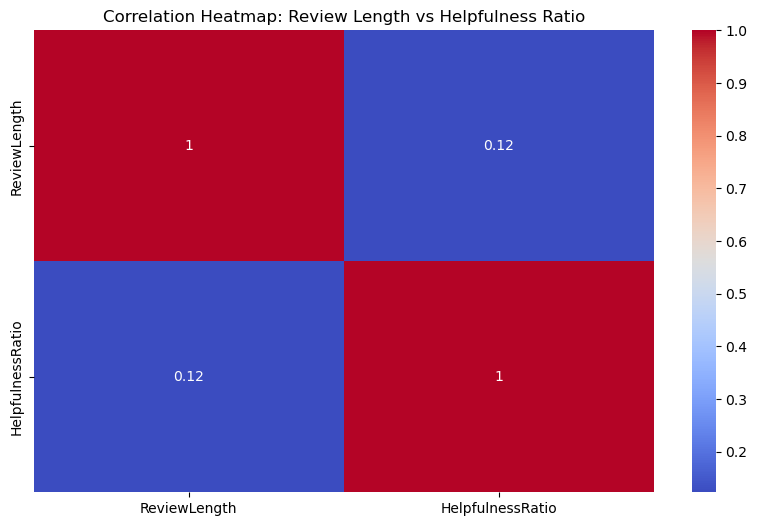

In [43]:
# Recommendations can be displayed in reports along with charts
plt.figure(figsize=(10,6))
sns.heatmap(correlation, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap: Review Length vs Helpfulness Ratio')
plt.show()